In [29]:
import os
import pandas as pd
import numpy as np
import scipy

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import seaborn as sns
import Bio.PDB
from scipy import stats
from Bio.PDB import SASA # SASA module won't load from newest version of Biopython for some reason
# import Geometry # Biopython Geometry module still not on main branch

import time
import sys
import glob
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')

import Geometry

## How to get the samples
MGnify - Text search - Samples analyses - Temperature slider + Assembly + InterPro family IPR006259

In [2]:
import pandas as pd

In [3]:
import glob

In [4]:
dfs = []
for file in glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGni*.csv'):
    print(file)
    df = pd.read_csv(file)
    print(len(df.columns))
    df.columns = ['mg_project', 'pipeline', 'experiment_type', 'sample_name', 'project_name', 'ENA_run', 'analysis', 'sra_sample']
    dfs.append(df.assign(temp_range=file.split('_assemblies_')[-1].split('.')[0]))

/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_assemblies_80+.csv
8
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_assemblies_70-80.csv
8
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_assemblies_60-70.csv
8
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_assemblies_50-60.csv
8
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_assemblies_40-50.csv
8
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnift_assemblies_10-20.csv
8
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_assemblies_20-30.csv
8
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_assemblies_2-10.csv
8
/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_assemblies_-20-0.csv
8


In [5]:
data = pd.concat(dfs)

In [6]:
data

,mg_project,pipeline,experiment_type,sample_name,project_name,ENA_run,analysis,sra_sample,temp_range
0,MGYS00005653,5.0,assembly,Uzon Caldera hot spring sediment,EMG produced TPA metagenomics assembly of PRJN...,ERZ1669248,SRS2704734,NaN,80+
1,MGYS00005688,5.0,assembly,TAT-1,EMG produced TPA metagenomics assembly of PRJN...,ERZ1669369,SRS1589162,NaN,80+
2,MGYS00005690,5.0,assembly,SAMD00155364,EMG produced TPA metagenomics assembly of PRJD...,ERZ1669411,DRS082834,NaN,80+
3,MGYS00005673,5.0,assembly,HCFilter,EMG produced TPA metagenomics assembly of PRJN...,ERZ1684501,SRS2907353,NaN,80+
4,MGYS00005675,5.0,assembly,WIBMP,EMG produced TPA metagenomics assembly of PRJN...,ERZ1684502,SRS5681002,NaN,80+
...,...,...,...,...,...,...,...,...,...
33,MGYS00002040,5.0,assembly,KD033_S9_78,EMG produced TPA metagenomics assembly of the ...,ERZ1749203,ERS1568972,NaN,-20-0
34,MGYS00002040,5.0,assembly,KD118_S3_32,EMG produced TPA metagenomics assembly of the ...,ERZ1748971,ERS1568994,NaN,-20-0
35,MGYS00002040,5.0,assembly,KD030_S9_81,EMG produced TPA metagenomics assembly of the ...,ERZ1749258,ERS1568968,NaN,-20-0
36,MGYS00002040,5.0,assembly,KD128_S10_40,EMG produced TPA metagenomics assembly of the ...,ERZ1748927,ERS1569005,NaN,-20-0


In [27]:
with open('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/runs.txt', 'w') as handle:
    handle.write('\n'.join(data['ENA_run'].unique()))

In [7]:
temp2ena = data.groupby('temp_range').apply(lambda x: x['ENA_run'].unique())

In [8]:
temp2ena.head()

temp_range
-20-0    [ERZ1748947, ERZ1756850, ERZ1749316, ERZ174917...
10-20    [ERZ4873633, ERZ4873545, ERZ4873493, ERZ487382...
2-10     [ERZ4873977, ERZ4874828, ERZ4874937, ERZ487410...
20-30    [ERZ4873593, ERZ4874076, ERZ4874608, ERZ487469...
40-50    [ERZ1673805, ERZ1673802, ERZ1669374, ERZ167377...
dtype: object

In [9]:
%%time
proteins_in_assemblies = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/mgy_proteins_temp_runs.txt', sep='\t', header=None)

CPU times: user 14.1 s, sys: 2.38 s, total: 16.5 s
Wall time: 16.4 s


In [10]:
proteins_in_assemblies.head()

,0,1
0,MGYP000000000017,ERZ1023645;ERZ1023658;ERZ1023679;ERZ1023696;ER...
1,MGYP000000000053,ERZ1023658;ERZ1023865;ERZ1023881;ERZ1023888;ER...
2,MGYP000000000086,ERZ1023658;ERZ1023785;ERZ1023865;ERZ1023921;ER...
3,MGYP000000000100,ERZ1023485;ERZ1023658;ERZ1023690;ERZ1023772;ER...
4,MGYP000000000111,ERZ1023921;ERZ1026780;ERZ1026788;ERZ1026808;ER...


In [11]:
pfam_proteins = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/mgy_PF00406_proteins.txt', sep='\t', header=None)

In [12]:
pfam_proteins.columns = ['protein', 'pfam', 'eval', 'bitscore', 'hmm_from', 'hmm_to', 'env_from', 'env_to']
pfam_proteins.head()

,protein,pfam,eval,bitscore,hmm_from,hmm_to,env_from,env_to
0,MGYP000000004017,PF00406,1.400000e-37,135.8,30,148,1,154
1,MGYP000000111032,PF00406,2.300000e-15,63.7,56,140,1,136
2,MGYP000000510723,PF00406,1.300000e-21,84.0,1,68,5,75
3,MGYP000000835013,PF00406,2.500000e-50,177.1,1,150,5,187
4,MGYP000001685672,PF00406,1.100000e-39,142.6,1,107,50,164


In [13]:
pfam_proteins = pfam_proteins[pfam_proteins['bitscore'] > 100]

In [14]:
adk_proteins = set(pfam_proteins['protein'].unique())

In [15]:
adk_proteins_in_assemblies = proteins_in_assemblies[proteins_in_assemblies[0].isin(adk_proteins)]

In [16]:
adk_proteins_in_assemblies.shape

(4274, 2)

In [17]:
from IPython.display import display, clear_output

In [18]:
tracker = dict((k, []) for k in temp2ena.index)
count = 0
for index, row in adk_proteins_in_assemblies.iterrows():
    num = 0
    last = None
    for index2, row2 in temp2ena.items():
        if len(set(row[1].split(';')).intersection(set(row2))) > 1:
            last = index2
            num += 1
    
    if num == 1:
        tracker[last].append(row[0])

    count += 1
    if count % 100 == 0:
        display(count)
        clear_output(wait=True)

        if all([len(item[1]) > 10 for item in tracker.items()]):
            print(f'Broke at {count}')
            break

4200

In [19]:
[len(item[1]) for item in tracker.items()]

[30, 100, 13, 87, 0, 10, 32, 0, 21]

In [20]:
esm_adks = [i for item in tracker.items() for i in item[1]]

## get structures from the ESM Atlas

In [21]:
import os

In [ ]:
count = 1
for e in esm_adks:
    display(count)
    clear_output(wait=True)
    os.system(f'wget https://api.esmatlas.com/fetchPredictedStructure/{e}.pdb -P /data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_pdbs/ --no-check-certificate')
    count += 1

Will not apply HSTS. The HSTS database must be a regular and non-world-writable file.
ERROR: could not open HSTS store at '/data/mhoffert/.wget-hsts'. HSTS will be disabled.
--2024-03-05 22:09:57--  https://api.esmatlas.com/fetchPredictedStructure/MGYP001288119876.pdb
Resolving api.esmatlas.com (api.esmatlas.com)... 44.194.44.23, 52.5.236.135, 18.207.88.201
Connecting to api.esmatlas.com (api.esmatlas.com)|44.194.44.23|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 403 Forbidden
2024-03-05 22:09:58 ERROR 403: Forbidden.



187

In [24]:
write_processed_pdbs = False

In [25]:
struct_dir = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/environment/MGnify_pdbs/'

In [33]:
pdb_files = set()
struct_path = os.path.join(os.getcwd(), struct_dir)
with os.scandir(struct_path) as d:
    for entry in d:
        if entry.name.endswith('.pdb') and entry.is_file():
            pdb_files.add(entry.name)

pdbs_dict = {}
for e in esm_adks:
    
    if e + '.pdb' in pdb_files:
        pdbs_dict[e] = []
        pdbs_dict[e].append(e + '.pdb')
# for genome in ogt_df['genome']:
#     pdbs_dict[genome] = []
#     if genome + '_closed.pdb' in pdb_files:
#         pdbs_dict[genome].append(genome + '_closed.pdb')
#         if genome + '_open.pdb' in pdb_files:
#             pdbs_dict[genome].append(genome + '_open.pdb')

In [34]:
# Prep settings for making plots
sns.set(font="Arial")
sns.set(font_scale=1.5)
sns.set_style('ticks')

In [35]:
from IPython.display import display, clear_output

In [36]:
# get structures and read them in
structs_dict = {}
parser = Bio.PDB.PDBParser()
count = 0
for genome, struct_names in pdbs_dict.items():
    if count % 10 == 0:
        display(count)
        clear_output(wait=True)
    for struct_name in struct_names:
        if struct_name.endswith('.pdb'):
            structs_dict[genome] = [parser.get_structure(struct_name.replace('.pdb',''), 
                                                              os.path.join(struct_path, struct_name))]
    count += 1

/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/Bio/PDB/PDBParser.py:388: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 1754
  warnings.warn(


80

## Calculating residue-level metrics and processing structures

In [37]:
# Calculate a bunch of residue-level metrics

df_collector = []

t1 = time.perf_counter()

io=Bio.PDB.PDBIO()
count = 0
for genome, structs in structs_dict.items():

    # if count % 10 == 0:
    display(count)
    clear_output(wait=True)

    struct = structs[0]
    temp_df = pd.DataFrame()
    
    # remove hydrogens
    #for atom in Bio.PDB.Selection.unfold_entities(struct, 'A'):
        #if atom.get_name()[0] == 'H':
            #Bio.PDB.Selection.unfold_entities(atom, 'R')[0].__delitem__(atom.id)
    
    queryable_protein = []
    for res in Bio.PDB.Selection.unfold_entities(struct, 'R'):
        if Bio.PDB.Polypeptide.is_aa(res, standard=True):
            queryable_protein.append(res)
    
    # iteratively remove residues at the termini with low pLDDT
    res_to_remove = []
    counter = 0
    res = queryable_protein[counter]
    while res['CA'].get_bfactor() < 70 and counter < 30:
        res_to_remove.append(res)
        counter += 1
        res = queryable_protein[counter]
        
    counter = 1
    res = queryable_protein[-counter]
    while res['CA'].get_bfactor() < 70 and counter < 30:
        res_to_remove.append(res)
        counter += 1
        res = queryable_protein[-counter]
        
    for res in res_to_remove:
        #struct[0]['A'].__delitem__(res.id)
        Bio.PDB.Selection.unfold_entities(res, 'C')[0].__delitem__(res.id)
    
    queryable_protein = []
    for res in Bio.PDB.Selection.unfold_entities(struct, 'R'):
        if Bio.PDB.Polypeptide.is_aa(res, standard=True):
            queryable_protein.append(res)
    
    # identify residues that are present, should be present, are not present, and are adjacent to residues that are not present
    # useful to avoid errors when running code that doesn't like missing residues or neighbors
    # not necessary for AF models but if we want to compare AF structures to crystal structures at any point it'll be handy
    residues_present = sorted([res.id[1] for res in queryable_protein])
    residues_range = list(range(residues_present[0], residues_present[-1] + 1))
    residues_absent = set(residues_range).difference(residues_present)
    residues_missing_nbrs = residues_absent.union({residues_range[0],residues_range[-1]},{resi+1 for resi in residues_absent},{resi-1 for resi in residues_absent})
    
    # set residue positions as indices for df
    temp_df['Position'] = residues_range
    temp_df = temp_df.set_index('Position')
    
    for chain in Bio.PDB.Selection.unfold_entities(list(queryable_protein), 'C'):
        if chain.id == 'A':
            temp_df = temp_df.copy()
            temp_df['Position'] = temp_df.index
            #temp_df['chain'] = chain.id

            # calculate contact density
            contact_cutoffs = [4.5]
            nbr_search = Bio.PDB.NeighborSearch(Bio.PDB.Selection.unfold_entities(chain, 'A'), bucket_size=1000)
            for cutoff in contact_cutoffs:
                contacts = nbr_search.search_all(cutoff, 'R')
                contact_count_dict = {resi: 0 if resi not in residues_absent else np.NaN for resi in temp_df['Position']}
                for (res1, res2) in contacts:
                    contact_count_dict[res1.id[1]] += 1
                    contact_count_dict[res2.id[1]] += 1
                temp_df[f'Contacts at {cutoff} Å'] = temp_df['Position'].map(contact_count_dict)

            # solvent exposure - Shrake-Rupley algorithm ("rolling ball" method)
            sr = SASA.ShrakeRupley(probe_radius=1.40, n_points=1000)
            sr.compute(struct[0], level="R") # note that this omits burial due to bound ligands or contacts with other chains    
            temp_df['SASA'] = temp_df['Position'].map(lambda pos: chain[pos].sasa if not pos in residues_absent else np.NaN)
            
            temp_df_m = temp_df.mean(numeric_only=True)
                        
            temp_df_m['genome'] = genome
            df_collector.append(temp_df_m)
            
            # save files with trimmed termini for analysis with rosetta
            if write_processed_pdbs:
                if not os.path.isdir('processed_structs'):
                    os.mkdir('processed_structs')
                    
                # remove hydrogens?
                if False:
                    for atom in Bio.PDB.Selection.unfold_entities(struct, 'A'):
                        if atom.get_name()[0] == 'H':
                            Bio.PDB.Selection.unfold_entities(atom, 'R')[0].__delitem__(atom.id)
                filename = struct.id + '_' + chain.id + '_processed' + '.pdb'
                io.set_structure(struct)
                io.save(os.path.join('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures', filename))

    count += 1
            
t2 = time.perf_counter()
print('Time elapsed:', t2-t1)

Time elapsed: 187.78881066013128


In [39]:
metrics_df = pd.concat(df_collector, axis=1)
metrics_df = metrics_df.T
# metrics_df = metrics_df.merge(ogt_df,on='genome')
metrics_df.head(5)

,Position,Contacts at 4.5 Å,SASA,genome
0,106.5,8.25,69.238314,MGYP000193633497
1,96.0,8.305344,68.081353,MGYP000208370970
2,61.5,7.483871,77.982284,MGYP000243767560
3,92.5,7.903226,73.167611,MGYP000565189599
4,110.5,8.4875,66.79848,MGYP000671337951


In [46]:
protein2temp = dict((i, item[0]) for item in tracker.items() for i in item[1])

In [47]:
metrics_df['temp'] = metrics_df['genome'].apply(lambda x: protein2temp[x])

/tmp/ipykernel_2100167/2529827650.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=metrics_df, x='temp', y='Contacts at 4.5 Å', palette='plasma')


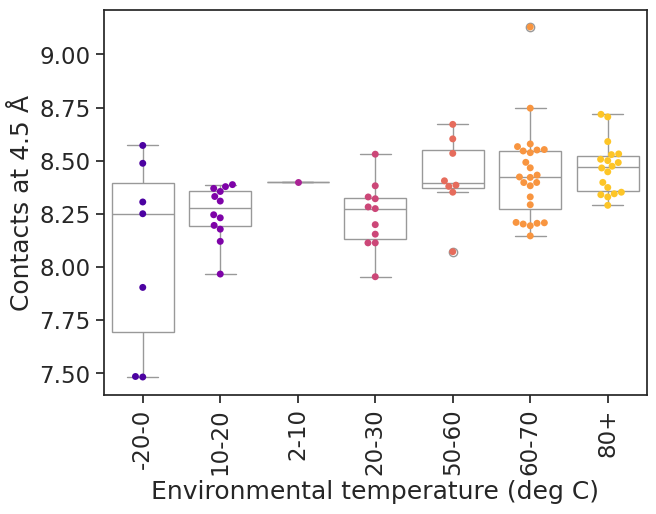

In [62]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=metrics_df, x='temp', y='Contacts at 4.5 Å', color='white')
sns.swarmplot(data=metrics_df, x='temp', y='Contacts at 4.5 Å', palette='plasma')

plt.tick_params(rotation=90, axis='x')
ax.set_xlabel('Environmental temperature (deg C)')
plt.savefig('env_temp_corr.png', dpi=400, bbox_inches='tight')
# ax.set_xlabel('Environmental temperature')

<Axes: xlabel='temp', ylabel='SASA'>

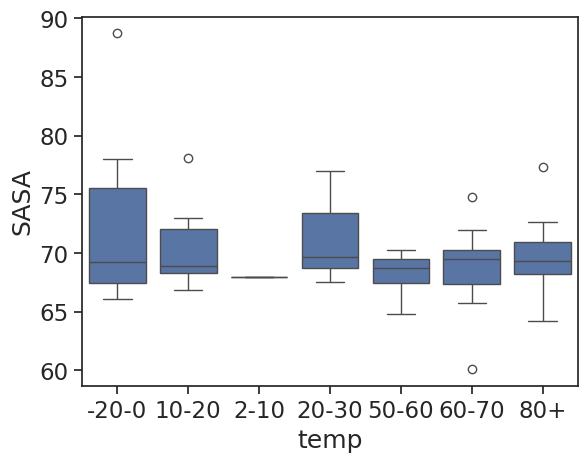

In [51]:
sns.boxplot(data=metrics_df, x='temp', y='SASA')

[('-20-0', 'MGYP000010812041'),
 ('-20-0', 'MGYP000028513667'),
 ('-20-0', 'MGYP000081584619'),
 ('-20-0', 'MGYP000158256557'),
 ('-20-0', 'MGYP000193633497'),
 ('-20-0', 'MGYP000205427631'),
 ('-20-0', 'MGYP000208370970'),
 ('-20-0', 'MGYP000214276988'),
 ('-20-0', 'MGYP000228578380'),
 ('-20-0', 'MGYP000243767560'),
 ('-20-0', 'MGYP000264408365'),
 ('-20-0', 'MGYP000267371656'),
 ('-20-0', 'MGYP000299801891'),
 ('-20-0', 'MGYP000338125772'),
 ('-20-0', 'MGYP000338130688'),
 ('-20-0', 'MGYP000388255523'),
 ('-20-0', 'MGYP000393705824'),
 ('-20-0', 'MGYP000397097619'),
 ('-20-0', 'MGYP000405940873'),
 ('-20-0', 'MGYP000456070822'),
 ('-20-0', 'MGYP000512111967'),
 ('-20-0', 'MGYP000538639857'),
 ('-20-0', 'MGYP000565189599'),
 ('-20-0', 'MGYP000624163203'),
 ('-20-0', 'MGYP000633007114'),
 ('-20-0', 'MGYP000668395018'),
 ('-20-0', 'MGYP000671337951'),
 ('-20-0', 'MGYP000706740352'),
 ('-20-0', 'MGYP000745065302'),
 ('-20-0', 'MGYP002178881378'),
 ('10-20', 'MGYP000023459241'),
 ('10-20